# Hi-Five — Train the XGBoost FSL Alphabet Model

Trains the XGBoost classifier from `data/landmarks.csv` (produced by
`python -m src.extract_features`) and saves the result to
`models/asl_xgb.json` and `models/label_encoder.pkl`.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

FEATURE_DIM = 90

CSV_PATH = Path("../data/landmarks_fsl.csv")
OUT_DIR = Path("../models")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print(f"CSV:    {CSV_PATH}")
print(f"Models: {OUT_DIR}")

CSV:    ..\data\landmarks_fsl.csv
Models: ..\models


## 1. Load the landmarks CSV

Reads the CSV produced by `extract_features.py`.

In [ ]:
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} samples")
df.head()

Loaded 17,469 samples


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f82,f83,f84,f85,f86,f87,f88,f89,label,source_image
0,0.0,0.0,0.0,0.403996,-0.072670,-0.171600,0.802876,-0.465735,-0.191036,0.902198,...,0.445631,0.288710,0.311058,0.507061,0.565896,-0.256127,-0.054849,0.388115,A,A/100_jpg.rf.4a2c7f393248bfc2d0e41808ab5606b2.jpg
1,0.0,0.0,0.0,-0.423890,-0.164737,-0.211017,-0.739858,-0.540365,-0.276840,-0.830558,...,0.423549,0.261974,0.316942,0.474295,-0.583590,-0.228164,-0.253825,0.369190,A,A/100_jpg.rf.7721058711ff09f33d7e95138ed08c9e.jpg
2,0.0,0.0,0.0,-0.447116,-0.129544,-0.238368,-0.786358,-0.502243,-0.318641,-0.909255,...,0.412853,0.257089,0.351052,0.521025,-0.593203,-0.227201,-0.291793,0.385505,A,A/100_jpg.rf.83c672054b3ed243053ff4cfc192805e.jpg
3,0.0,0.0,0.0,-0.432591,-0.132233,-0.216806,-0.784869,-0.490058,-0.295911,-0.917144,...,0.388084,0.227644,0.331738,0.501840,-0.545124,-0.220570,-0.326648,0.362327,A,A/101_jpg.rf.22d99144f7ad7249833546a901987bd5.jpg
4,0.0,0.0,0.0,-0.451012,-0.117695,-0.211591,-0.802011,-0.510568,-0.275141,-0.932407,...,0.399175,0.239868,0.341319,0.516006,-0.571423,-0.239149,-0.271557,0.374092,A,A/101_jpg.rf.264b63cc53bba41d597787db19faf85d.jpg


28 classes total



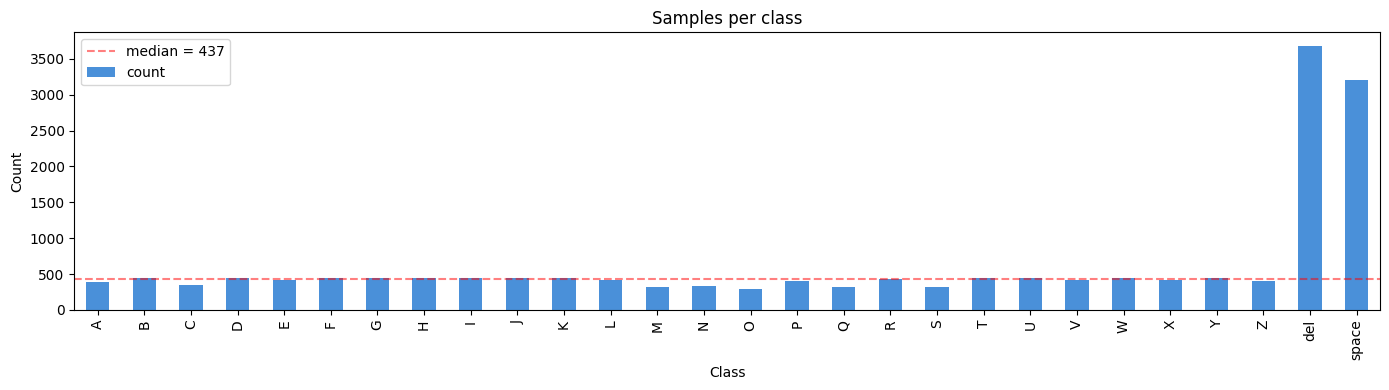

label
A         384
B         446
C         354
D         440
E         419
F         450
G         446
H         446
I         444
J         446
K         443
L         420
M         314
N         337
O         299
P         409
Q         314
R         435
S         319
T         443
U         450
V         414
W         440
X         420
Y         440
Z         409
del      3685
space    3203
Name: count, dtype: int64

In [ ]:
class_counts = df["label"].value_counts().sort_index()
print(f"{len(class_counts)} classes total\n")

fig, ax = plt.subplots(figsize=(14, 4))
class_counts.plot(kind="bar", ax=ax, color="#4a90d9")
ax.set_title("Samples per class")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.axhline(class_counts.median(), color="red", linestyle="--", alpha=0.5,
           label=f"median = {int(class_counts.median())}")
ax.legend()
plt.tight_layout()
plt.show()

class_counts

## 2. Encode labels and split train/test

XGBoost needs integer labels, so we use `LabelEncoder` to translate
`A`, `B`, `C`, ... → `0`, `1`, `2`, ...

80/20 stratified split

In [ ]:
feature_cols = [f"f{i}" for i in range(FEATURE_DIM)]
X = df[feature_cols].to_numpy(dtype=np.float32)
y_str = df["label"].to_numpy()

le = LabelEncoder()
y = le.fit_transform(y_str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"Classes: {list(le.classes_)}")

X_train: (13975, 90)  X_test: (3494, 90)
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'space']


## 3. Hyperparameters

You can edit this cell and re-run the training cell below without
reloading the CSV — that's the main reason to be in a notebook
instead of running `train.py`.

Defaults match `train.py` and are based on the reference repo
(98.43% accuracy). Sensible knobs to try:
- `n_estimators` — more trees → better fit, slower train. 100–500 is the useful range.
- `max_depth` — deeper trees → more complex patterns, more risk of overfitting. 4–8 is normal.
- `learning_rate` — smaller → needs more trees but generalizes better. 0.05–0.3 is normal.

In [ ]:
params = dict(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
)


params

{'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1}

## 4. Train the model

In [ ]:
clf = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    tree_method="hist",
    n_jobs=-1,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    **params,
)

clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)
print("Training complete.")

Training complete.


## 5. Evaluate

Test accuracy + per-class precision/recall/F1.

In [ ]:
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc * 100:.2f}%\n")

print("Classification report:")
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    digits=3,
))

Test accuracy: 98.86%

Classification report:
              precision    recall  f1-score   support

           A      0.949     0.974     0.962        77
           B      0.989     0.989     0.989        89
           C      0.959     0.986     0.972        71
           D      1.000     1.000     1.000        88
           E      1.000     1.000     1.000        84
           F      1.000     1.000     1.000        90
           G      1.000     1.000     1.000        89
           H      1.000     1.000     1.000        89
           I      1.000     0.989     0.994        89
           J      0.989     1.000     0.994        89
           K      1.000     1.000     1.000        88
           L      1.000     0.976     0.988        84
           M      0.953     0.968     0.961        63
           N      1.000     0.955     0.977        67
           O      0.934     0.950     0.942        60
           P      1.000     0.988     0.994        82
           Q      0.969     0.984  

## 6. Confusion matrix

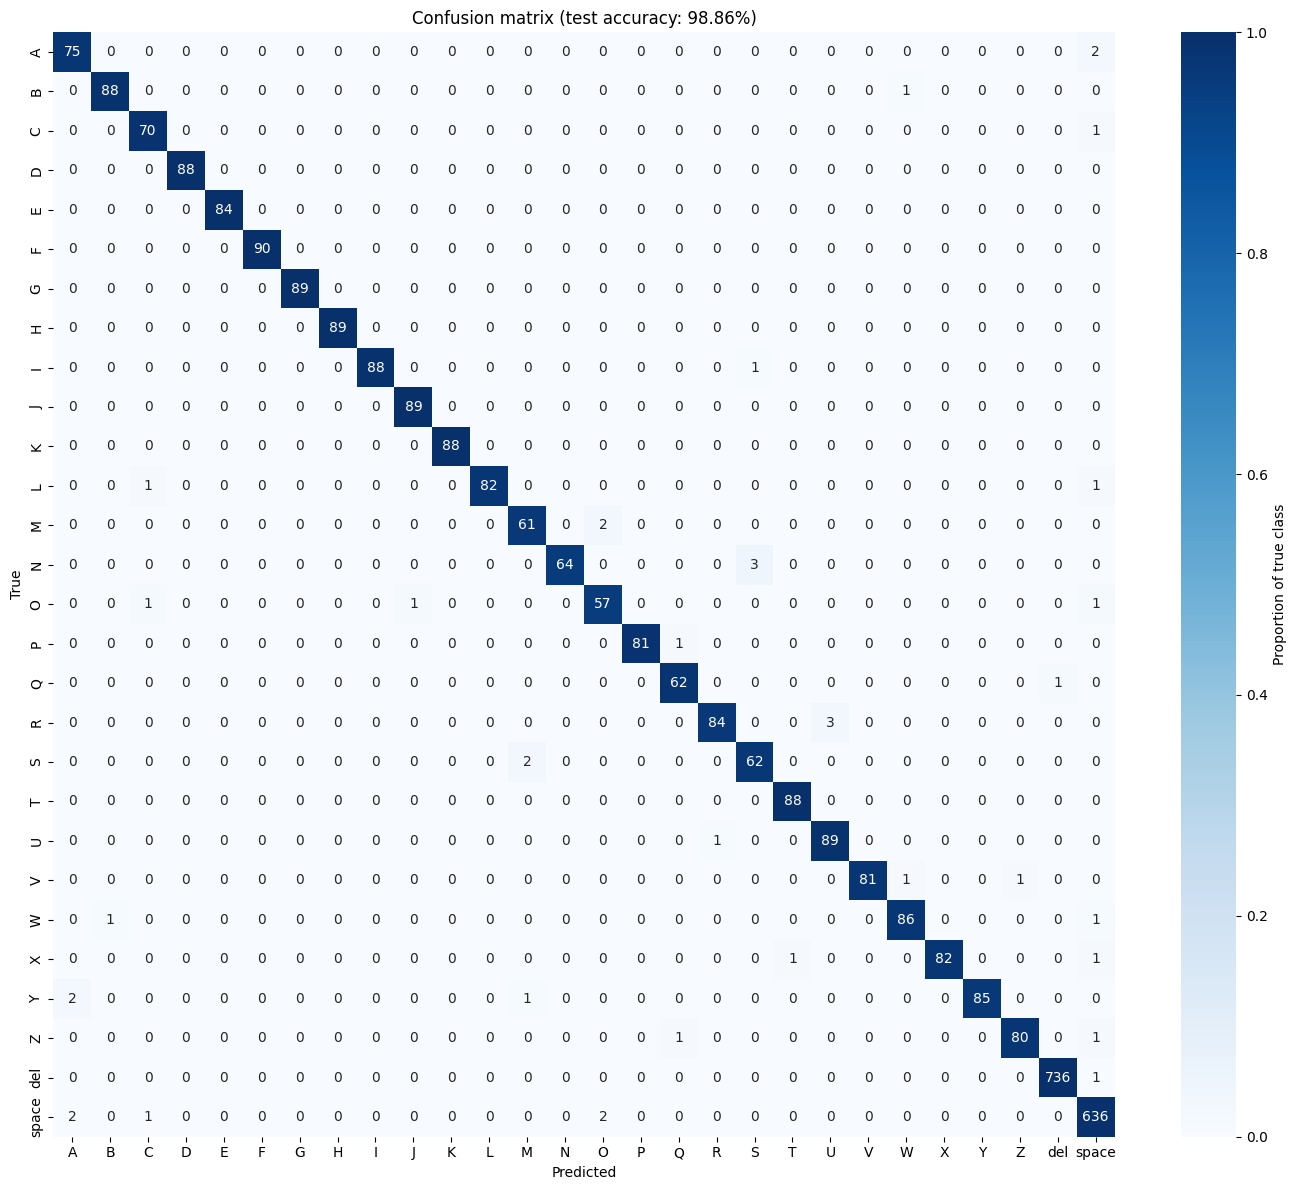

In [ ]:
cm = confusion_matrix(y_test, y_pred)

cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm_norm,
    annot=cm,            
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cbar_kws={"label": "Proportion of true class"},
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix (test accuracy: {acc * 100:.2f}%)")
plt.tight_layout()
plt.show()

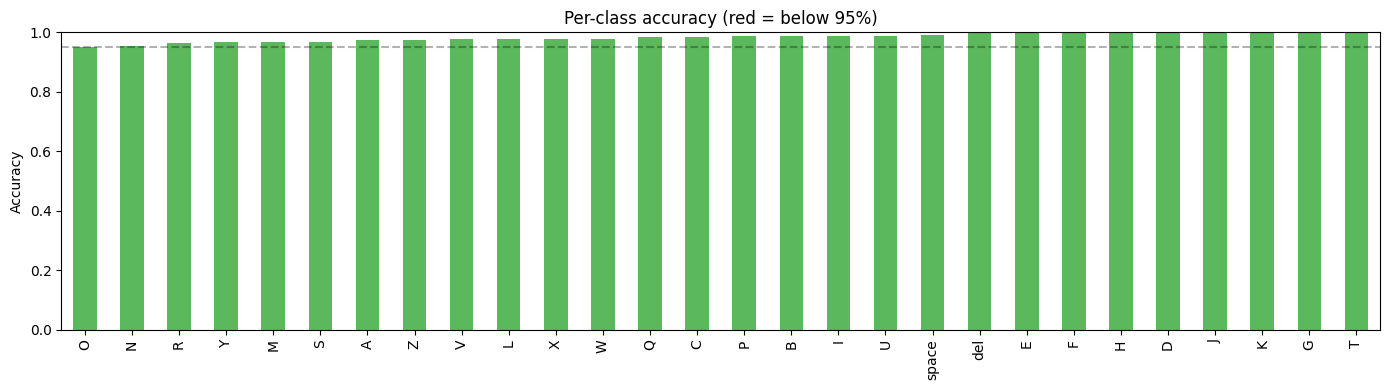

O        0.950000
N        0.955224
R        0.965517
Y        0.965909
M        0.968254
S        0.968750
A        0.974026
Z        0.975610
V        0.975904
L        0.976190
X        0.976190
W        0.977273
Q        0.984127
C        0.985915
P        0.987805
B        0.988764
I        0.988764
U        0.988889
space    0.992200
del      0.998643
E        1.000000
F        1.000000
H        1.000000
D        1.000000
J        1.000000
K        1.000000
G        1.000000
T        1.000000
Name: accuracy, dtype: float64

In [ ]:
per_class_acc = pd.Series(
    cm.diagonal() / cm.sum(axis=1),
    index=le.classes_,
    name="accuracy",
).sort_values()

fig, ax = plt.subplots(figsize=(14, 4))
colors = ["#d9534f" if a < 0.95 else "#5cb85c" for a in per_class_acc]
per_class_acc.plot(kind="bar", ax=ax, color=colors)
ax.set_title("Per-class accuracy (red = below 95%)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.0)
ax.axhline(0.95, color="black", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

per_class_acc

## 7. Feature importance

To tell which of the 63 landmark coordinates does XGBoost rely on most 

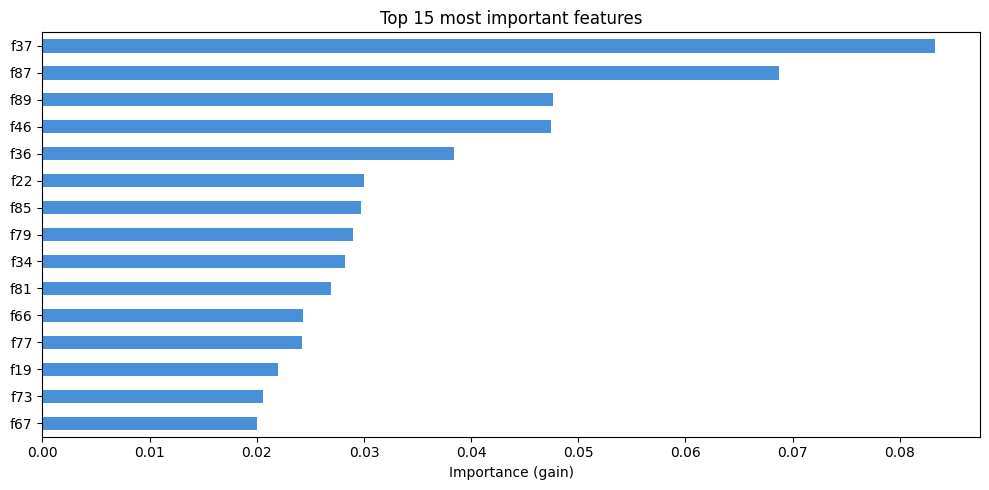

In [10]:
# Top-15 most important features
importance = pd.Series(
    clf.feature_importances_,
    index=feature_cols,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importance.head(15).plot(kind="barh", ax=ax, color="#4a90d9")
ax.invert_yaxis()
ax.set_title("Top 15 most important features")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()
plt.show()

## 8. Save the model

Writes the trained model and label encoder to `models/`. These are
the same two files `predict.py` and `test_webcam.py` load.

In [ ]:
model_path = OUT_DIR / "fsl_xgb.json"
encoder_path = OUT_DIR / "fsl_label_encoder.pkl"

clf.save_model(str(model_path))
joblib.dump(le, encoder_path)

print(f"Model:   {model_path}  ({model_path.stat().st_size / 1024:.1f} KB)")
print(f"Encoder: {encoder_path}  ({encoder_path.stat().st_size / 1024:.1f} KB)")

Model:   ..\models\fsl_xgb.json  (6917.8 KB)
Encoder: ..\models\fsl_label_encoder.pkl  (0.6 KB)


## Next steps

The model is saved. 

To test the webcam first:

```cmd
python -m src.test_webcam --model models/fsl_xgb.json --encoder models/fsl_label_encoder.pkl
```
